# Wasserstein Distance — Anomaly Detection

Uses **Sliced Wasserstein Distance (SWD)** on PCA-reduced embeddings (2048 → 50 dims).

Two-phase analysis:
- **Phase 1** — Artist vs Global: how stylistically distinct is each artist from the full Impressionism distribution?
- **Phase 2** — Per-painting score: for each painting, compare its local neighbourhood (KNN) to the global distribution — paintings in unusual regions score high

Results are saved to `results/` for cross-method comparison with cosine similarity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wasserstein_distance
from tqdm import tqdm

BASE_DIR = Path('..')
EMBEDDINGS_DIR = BASE_DIR / 'embeddings'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Load
embeddings_raw = np.load(EMBEDDINGS_DIR / 'image_embeddings.npy')
metadata = pd.read_csv(EMBEDDINGS_DIR / 'embedding_metadata.csv').reset_index(drop=True)

# L2-normalise before PCA
embeddings_norm = normalize(embeddings_raw, norm='l2')

print('Embeddings shape:', embeddings_raw.shape)
print('Metadata shape:  ', metadata.shape)

Embeddings shape: (1500, 2048)
Metadata shape:   (1500, 11)


## Step 1 — PCA Reduction (2048 → 50 dims)

Wasserstein in 2048 dimensions is intractable. PCA to 50 components retains most variance while making SWD fast and stable.

Variance explained by 50 components: 58.28%


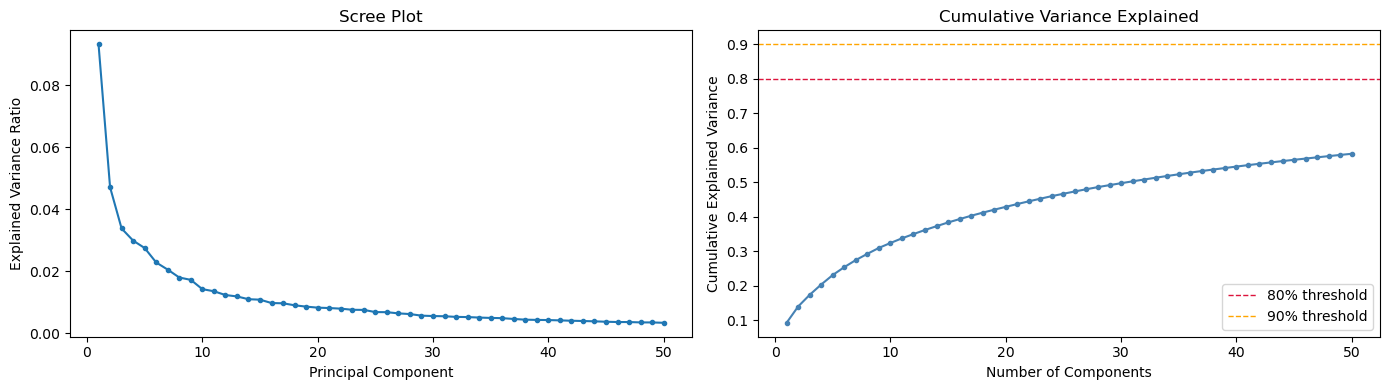

In [2]:
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_norm)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f'Variance explained by {N_COMPONENTS} components: {cumvar[-1]:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.arange(1, N_COMPONENTS + 1), pca.explained_variance_ratio_, marker='o', markersize=3)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(np.arange(1, N_COMPONENTS + 1), cumvar, marker='o', markersize=3, color='steelblue')
axes[1].axhline(0.80, color='crimson', linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', linewidth=1, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'wasserstein_pca_variance.png', dpi=150)
plt.show()

## Helper — Sliced Wasserstein Distance

Projects two point clouds onto `n_projections` random 1D directions, computes Wasserstein distance on each projection, and returns the mean. Handles high-dimensional distributions efficiently.

In [3]:
def sliced_wasserstein_distance(X, Y, n_projections=200, random_state=42):
    """Sliced Wasserstein Distance between two point clouds X and Y.
    X: (n, d), Y: (m, d) — must have same number of dimensions.
    """
    rng = np.random.RandomState(random_state)
    d = X.shape[1]
    directions = rng.randn(n_projections, d)
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)

    X_proj = X @ directions.T  # (n, n_projections)
    Y_proj = Y @ directions.T  # (m, n_projections)

    return np.mean([
        wasserstein_distance(X_proj[:, i], Y_proj[:, i])
        for i in range(n_projections)
    ])

print('SWD helper ready.')

SWD helper ready.


---
## Phase 1 — Artist vs Global Distribution

For each qualified artist (≥ 20 images), compute SWD between that artist's embeddings and the full 1,500-painting distribution.

High SWD → artist's style sits far from the genre centre → stylistically distinct.

In [4]:
MIN_IMAGES = 20
artist_counts = metadata['artist'].value_counts()
qualified_artists = artist_counts[artist_counts >= MIN_IMAGES].index.tolist()
print(f'Qualified artists: {len(qualified_artists)}')

artist_swd = {}
for artist in tqdm(qualified_artists, desc='Artist vs Global SWD'):
    idx = metadata[metadata['artist'] == artist].index.tolist()
    artist_emb = embeddings_pca[idx]
    swd = sliced_wasserstein_distance(artist_emb, embeddings_pca, n_projections=200)
    artist_swd[artist] = swd

artist_swd_df = (
    pd.DataFrame.from_dict(artist_swd, orient='index', columns=['swd_vs_global'])
    .sort_values('swd_vs_global', ascending=False)
    .reset_index()
    .rename(columns={'index': 'artist'})
)
artist_swd_df['n_images'] = artist_swd_df['artist'].map(artist_counts)
print(artist_swd_df.to_string(index=False))

Qualified artists: 14


Artist vs Global SWD: 100%|██████████| 14/14 [00:01<00:00, 12.31it/s]

               artist  swd_vs_global  n_images
         mary cassatt       0.049452        28
        alfred sisley       0.042522        64
        eugene boudin       0.042336        59
       berthe morisot       0.041110        31
          edgar degas       0.037505        64
pierre auguste renoir       0.035420       165
     joaquã­n sorolla       0.035129        39
  john singer sargent       0.033386        33
  gustave caillebotte       0.030755        24
         claude monet       0.029118       169
   konstantin korovin       0.028095        26
     camille pissarro       0.027600        91
william merritt chase       0.027508        43
        childe hassam       0.027007        59


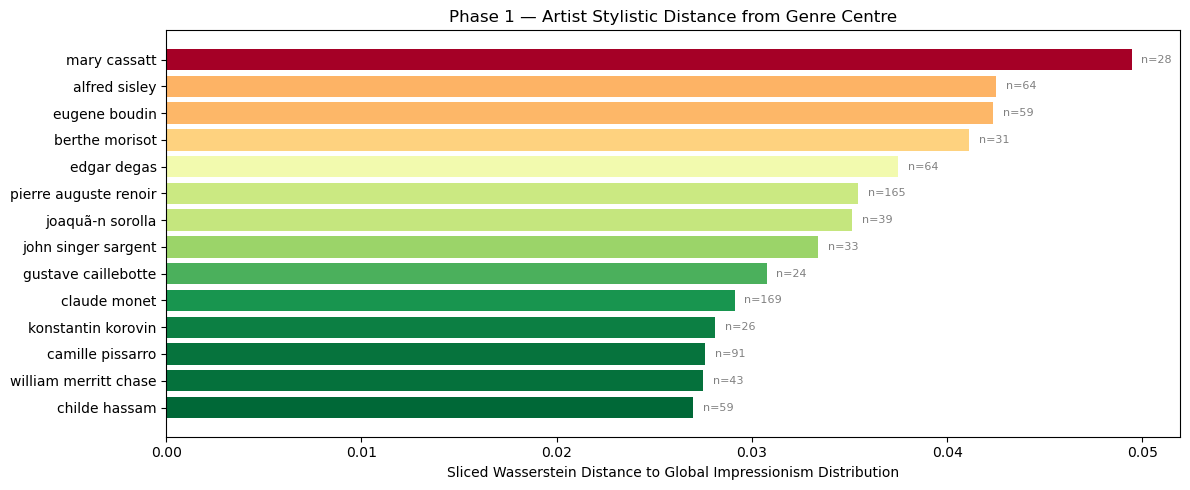

In [5]:
# --- Bar chart: artist SWD vs global ---
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn_r(
    (artist_swd_df['swd_vs_global'] - artist_swd_df['swd_vs_global'].min()) /
    (artist_swd_df['swd_vs_global'].max() - artist_swd_df['swd_vs_global'].min())
)
bars = ax.barh(artist_swd_df['artist'], artist_swd_df['swd_vs_global'], color=colors)
ax.set_xlabel('Sliced Wasserstein Distance to Global Impressionism Distribution')
ax.set_title('Phase 1 — Artist Stylistic Distance from Genre Centre')
ax.invert_yaxis()

# Annotate image count
for bar, n in zip(bars, artist_swd_df['n_images']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'n={n}', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_wasserstein_artist_vs_global.png', dpi=150)
plt.show()

In [6]:
# Save Phase 1
artist_swd_df.to_csv(RESULTS_DIR / 'wasserstein_phase1_artist_vs_global.csv', index=False)
print('Saved → results/wasserstein_phase1_artist_vs_global.csv')

Saved → results/wasserstein_phase1_artist_vs_global.csv


---
## Phase 2 — Per-Painting Anomaly Score (KNN Neighbourhood vs Global)

For each painting, find its K nearest neighbours and compute SWD between that local neighbourhood and the full global distribution.

- A painting in a **dense, typical region** → its KNN looks like the global distribution → low SWD
- A painting in an **unusual region** → its KNN is concentrated and atypical → high SWD → anomaly

In [7]:
K = 20  # neighbourhood size

# Precompute KNN on PCA-reduced embeddings
nn = NearestNeighbors(n_neighbors=K + 1, metric='cosine', n_jobs=-1)
nn.fit(embeddings_pca)
_, knn_indices = nn.kneighbors(embeddings_pca)
knn_indices = knn_indices[:, 1:]  # exclude self

print(f'KNN index built (K={K}).')

KNN index built (K=20).


In [8]:
# Compute per-painting SWD score
painting_swd = np.zeros(len(metadata))

for i in tqdm(range(len(metadata)), desc='Per-painting SWD'):
    neighbourhood = embeddings_pca[knn_indices[i]]   # (K, 50)
    painting_swd[i] = sliced_wasserstein_distance(
        neighbourhood, embeddings_pca, n_projections=100
    )

metadata['painting_swd'] = painting_swd
metadata['painting_swd_norm'] = (
    (painting_swd - painting_swd.min()) /
    (painting_swd.max() - painting_swd.min())
)  # normalised 0-1 for easy comparison

print(f'Mean SWD : {painting_swd.mean():.5f}')
print(f'Std      : {painting_swd.std():.5f}')
print(f'Min      : {painting_swd.min():.5f}')
print(f'Max      : {painting_swd.max():.5f}')

Per-painting SWD: 100%|██████████| 1500/1500 [00:42<00:00, 35.43it/s]


Mean SWD : 0.05794
Std      : 0.00770
Min      : 0.03791
Max      : 0.08180


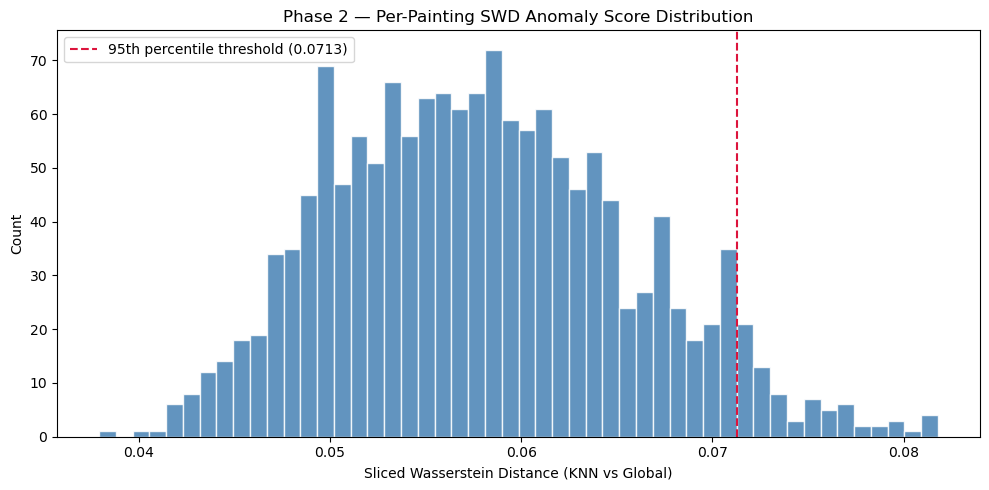

Flagged as anomalies (top 5%): 75 paintings


In [9]:
# --- Histogram of per-painting SWD scores ---
threshold = np.percentile(painting_swd, 95)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(painting_swd, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(threshold, color='crimson', linestyle='--', linewidth=1.5,
           label=f'95th percentile threshold ({threshold:.4f})')
ax.set_xlabel('Sliced Wasserstein Distance (KNN vs Global)')
ax.set_ylabel('Count')
ax.set_title('Phase 2 — Per-Painting SWD Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase2_wasserstein_painting_histogram.png', dpi=150)
plt.show()
print(f'Flagged as anomalies (top 5%): {(painting_swd >= threshold).sum()} paintings')

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


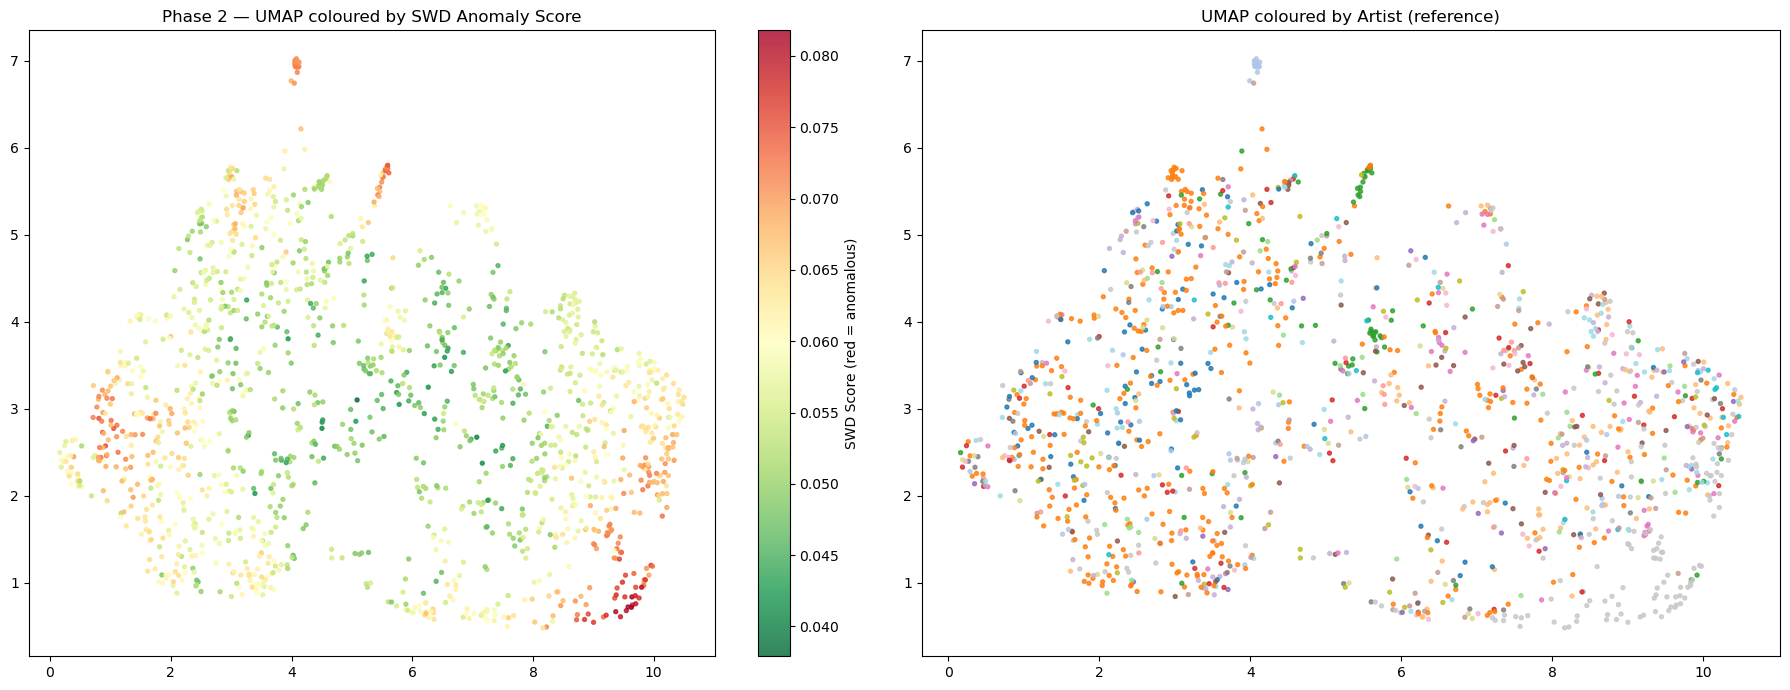

In [10]:
# --- UMAP coloured by SWD anomaly score ---
try:
    import umap
except ImportError:
    raise ImportError('Install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords = reducer.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: SWD anomaly score
sc = axes[0].scatter(coords[:, 0], coords[:, 1],
                     c=painting_swd, cmap='RdYlGn_r',
                     s=8, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='SWD Score (red = anomalous)')
axes[0].set_title('Phase 2 — UMAP coloured by SWD Anomaly Score')

# Right: artist identity for reference
artist_codes = metadata['artist'].astype('category').cat.codes
sc2 = axes[1].scatter(coords[:, 0], coords[:, 1],
                      c=artist_codes, cmap='tab20',
                      s=8, alpha=0.8)
axes[1].set_title('UMAP coloured by Artist (reference)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase2_wasserstein_umap.png', dpi=150)
plt.show()

In [11]:
# --- Top 20 anomalies by SWD ---
top_anomalies = (
    metadata[['filename', 'artist', 'painting_swd', 'painting_swd_norm']]
    .sort_values('painting_swd', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print('Top 20 anomalies by SWD:')
top_anomalies.style.background_gradient(subset=['painting_swd'], cmap='Reds')

Top 20 anomalies by SWD:


,filename,artist,painting_swd,painting_swd_norm
0,Impressionism/pierre-auguste-renoir_girl-in-a-red-hat-1913.jpg,pierre auguste renoir,0.081800,1.000000
1,Impressionism/pierre-auguste-renoir_woman-in-a-hat-with-flowers-1917.jpg,pierre auguste renoir,0.081520,0.993627
2,Impressionism/pierre-auguste-renoir_woman-in-a-red-blouse-1.jpg,pierre auguste renoir,0.081497,0.993100
3,Impressionism/pierre-auguste-renoir_bust-of-a-young-girl-in-a-straw-hat-1917.jpg,pierre auguste renoir,0.080934,0.980270
4,Impressionism/pierre-auguste-renoir_portrait-of-a-woman-1911.jpg,pierre auguste renoir,0.080633,0.973420
5,Impressionism/pierre-auguste-renoir_portrait-of-mademoiselle-francois.jpg,pierre auguste renoir,0.080031,0.959707
6,Impressionism/pierre-auguste-renoir_dancer-with-castenets-1895.jpg,pierre auguste renoir,0.079401,0.945354
7,Impressionism/pierre-auguste-renoir_woman-s-head-2.jpg,pierre auguste renoir,0.079326,0.943646
8,Impressionism/pierre-auguste-renoir_seated-woman-in-a-blue-dress-1915.jpg,pierre auguste renoir,0.079040,0.937130
9,Impressionism/pierre-auguste-renoir_blond-in-a-straw-hat-seated-girl.jpg,pierre auguste renoir,0.078932,0.934672


---
## Cross-Method Comparison — SWD vs Cosine Similarity

Compare which paintings both methods agree are anomalous.
Agreement between methods = stronger evidence of a true anomaly.

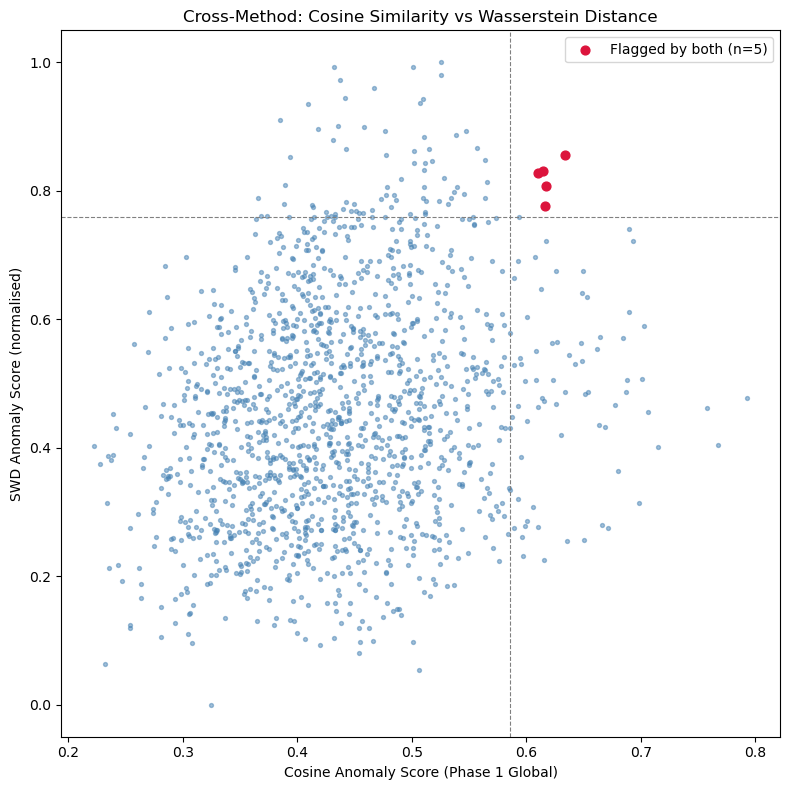

Paintings flagged by both methods: 5
                                                                   filename                 artist  global_anomaly_score  painting_swd_norm
30    Impressionism/pierre-auguste-renoir_marie-louise-durand-ruel-1898.jpg  pierre auguste renoir              0.633465           0.856014
776                   Impressionism/eugene-boudin_the-port-at-deauville.jpg          eugene boudin              0.617426           0.807683
1271             Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg           claude monet              0.614853           0.830769
1360       Impressionism/pierre-auguste-renoir_woman-at-the-garden-1873.jpg  pierre auguste renoir              0.616220           0.776764
1392            Impressionism/pierre-auguste-renoir_young-woman-reading.jpg  pierre auguste renoir              0.610034           0.828410


In [12]:
cosine_path = RESULTS_DIR / 'phase1_global_cosine_scores.csv'
if cosine_path.exists():
    cosine_df = pd.read_csv(cosine_path)
    merged = metadata[['filename', 'artist', 'painting_swd', 'painting_swd_norm']].merge(
        cosine_df[['filename', 'global_anomaly_score']], on='filename', how='inner'
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(merged['global_anomaly_score'], merged['painting_swd_norm'],
               s=8, alpha=0.5, color='steelblue')

    # Threshold: top 5% on each method
    c_thresh = np.percentile(merged['global_anomaly_score'], 95)
    w_thresh = np.percentile(merged['painting_swd_norm'], 95)
    both = merged[(merged['global_anomaly_score'] >= c_thresh) &
                  (merged['painting_swd_norm'] >= w_thresh)]

    ax.scatter(both['global_anomaly_score'], both['painting_swd_norm'],
               s=40, color='crimson', zorder=5, label=f'Flagged by both (n={len(both)})')
    ax.axvline(c_thresh, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(w_thresh, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Cosine Anomaly Score (Phase 1 Global)')
    ax.set_ylabel('SWD Anomaly Score (normalised)')
    ax.set_title('Cross-Method: Cosine Similarity vs Wasserstein Distance')
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cross_method_cosine_vs_wasserstein.png', dpi=150)
    plt.show()

    print(f'Paintings flagged by both methods: {len(both)}')
    print(both[['filename', 'artist', 'global_anomaly_score', 'painting_swd_norm']].to_string())
else:
    print('Cosine scores not found — run cosine_similarity_analysis.ipynb first.')

In [13]:
# Save Phase 2 scores
metadata[['filename', 'artist', 'painting_swd', 'painting_swd_norm']].to_csv(
    RESULTS_DIR / 'wasserstein_phase2_painting_scores.csv', index=False
)
print('Saved → results/wasserstein_phase2_painting_scores.csv')
print()
print('All done. Next: Isolation Forest on the same embeddings.')

Saved → results/wasserstein_phase2_painting_scores.csv

All done. Next: Isolation Forest on the same embeddings.
